# Heart Disease Machine Learning Pipeline
An end-to-end ML pipeline for the UCI Heart Disease Dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

## 1. Data Preprocessing & Cleaning
- Load the dataset
- Handle missing values
- Perform data encoding
- Standardize numerical features
- EDA

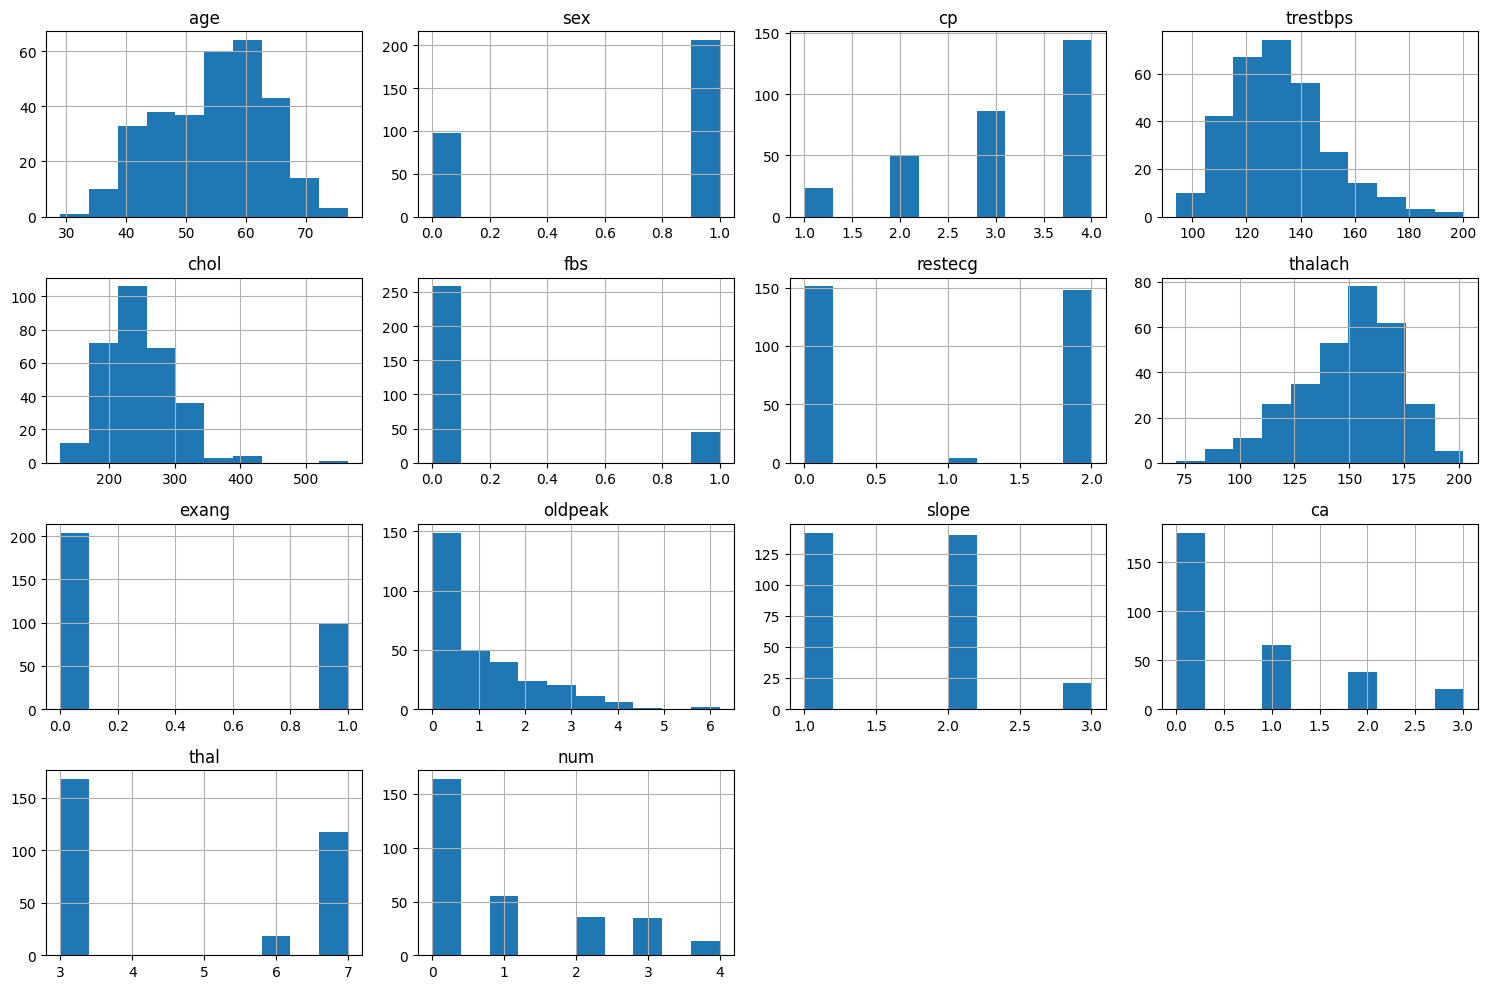

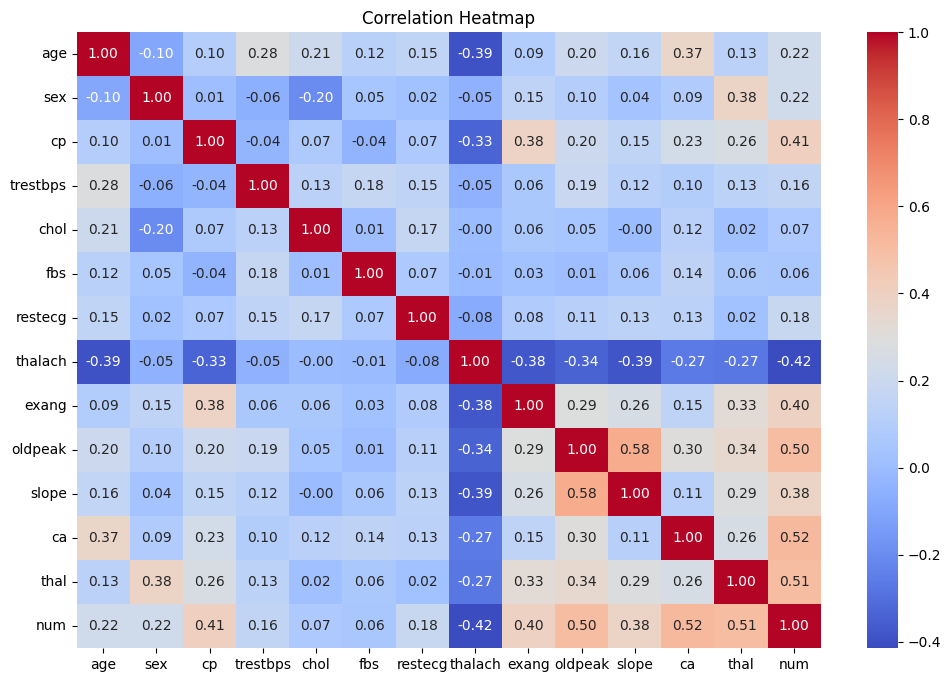

Data Preprocessing Complete.


In [2]:
# Load the dataset
df = pd.read_csv('../data/heart_disease.csv')

# Handle missing values (Imputation with median)
df.fillna(df.median(), inplace=True)

# EDA - Histograms
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

# EDA - Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Data Encoding (One-hot encoding for categorical variables)
# The dataset has some categorical features like cp, restecg, slope, thal
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df.drop('num', axis=1) if 'num' in df.columns else df.drop('target', axis=1, errors='ignore')
# If target column is not named target or num, let's find it. Usually it's the last column or named 'num'/'target'
target_col = 'num' if 'num' in df.columns else 'target'
y = df[target_col]

# Convert target to binary (0 = no disease, >0 = disease)
y = (y > 0).astype(int)

# Standardize numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("Data Preprocessing Complete.")

## 2. Dimensionality Reduction - PCA
- Apply PCA
- Determine optimal components
- Visualize results

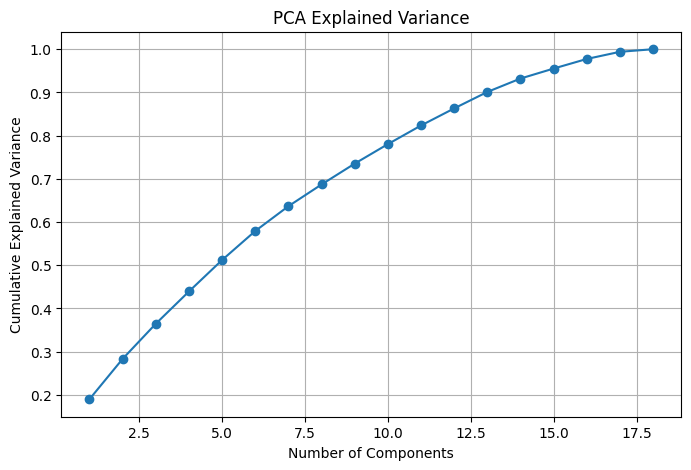

Optimal number of components retaining 95% variance: 15


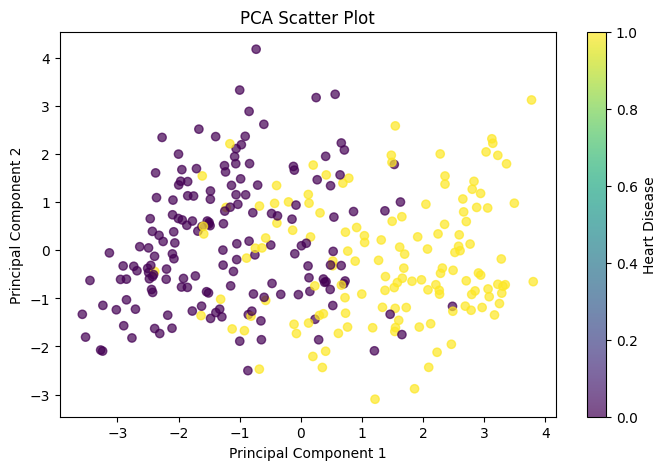

In [3]:
pca = PCA()
pca.fit(X_scaled)

# Cumulative variance plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

# Apply PCA with 95% variance
pca_optimal = PCA(n_components=0.95)
X_pca = pca_optimal.fit_transform(X_scaled)
print(f"Optimal number of components retaining 95% variance: {pca_optimal.n_components_}")

# Scatter plot of first two components
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter Plot')
plt.colorbar(label='Heart Disease')
plt.show()

## 3. Feature Selection
- Feature Importance (Random Forest)
- RFE
- Chi-Square Test

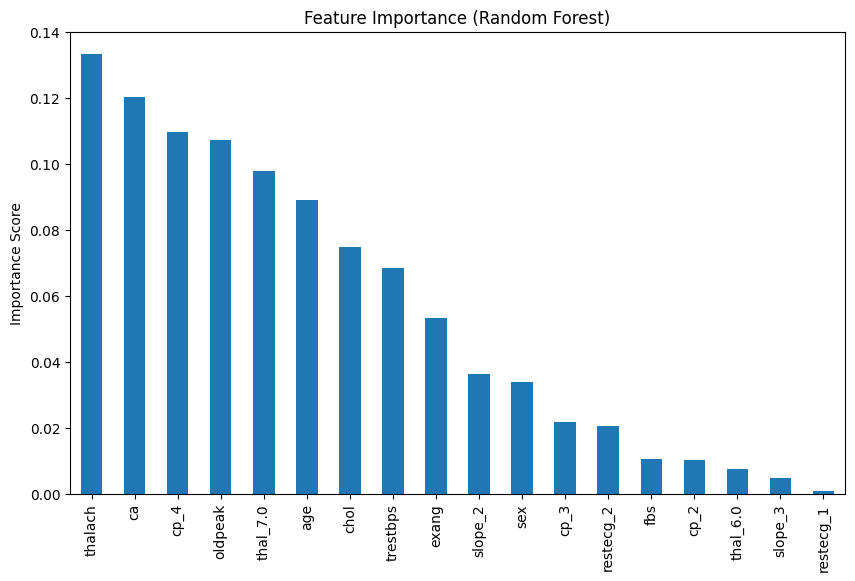

Top 10 features selected by RFE: ['sex', 'trestbps', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_2', 'cp_4', 'slope_2', 'thal_7.0']
Top 10 features selected by Chi-Square: ['sex', 'exang', 'oldpeak', 'ca', 'cp_2', 'cp_3', 'cp_4', 'restecg_2', 'slope_2', 'thal_7.0']
Feature Selection Complete.


In [4]:
# Feature Importance using Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance Score')
plt.show()

# RFE (Recursive Feature Elimination)
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10)
rfe.fit(X_scaled, y)
selected_features_rfe = X.columns[rfe.support_]
print(f"Top 10 features selected by RFE: {list(selected_features_rfe)}")

# Chi-Square Test (requires non-negative values, so we use MinMaxScaler for this specific test)
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), columns=X.columns)
chi2_selector = SelectKBest(chi2, k=10)
chi2_selector.fit(X_minmax, y)
selected_features_chi2 = X.columns[chi2_selector.get_support()]
print(f"Top 10 features selected by Chi-Square: {list(selected_features_chi2)}")

# For modeling, we will use the most important features (Let's use RFE selected)
X_final = X_scaled[selected_features_rfe]
print("Feature Selection Complete.")

## 4. Supervised Learning - Classification Models
- Train/Test Split
- Train Models: Logistic Regression, Decision Tree, Random Forest, SVM
- Evaluate with metrics & ROC Curve

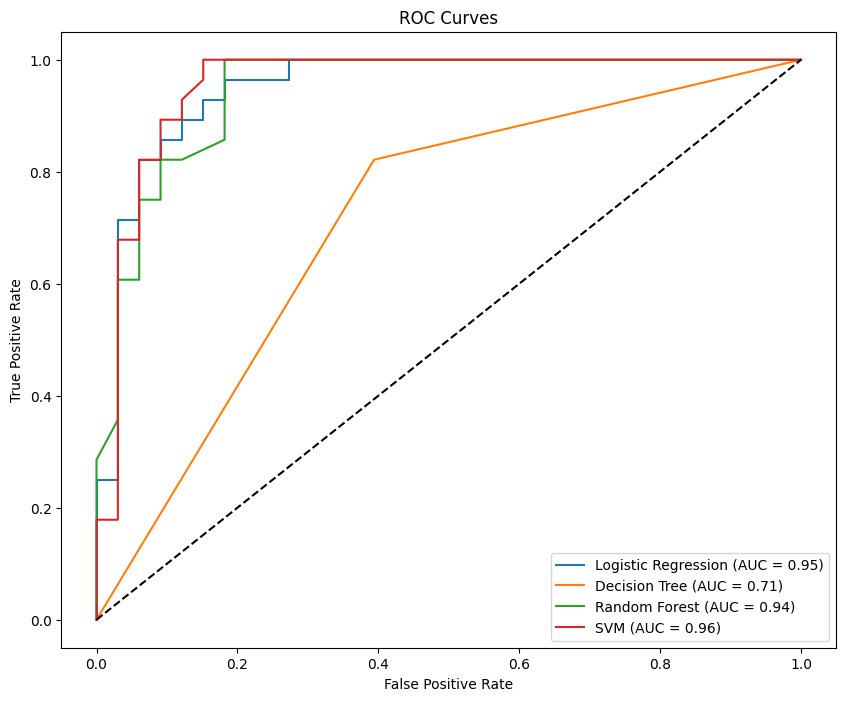

                     Accuracy  Precision    Recall        F1       AUC
Model                                                                 
Logistic Regression  0.868852   0.812500  0.928571  0.866667  0.950216
Decision Tree        0.704918   0.638889  0.821429  0.718750  0.713745
Random Forest        0.836066   0.800000  0.857143  0.827586  0.944805
SVM                  0.901639   0.866667  0.928571  0.896552  0.955087


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc_score})
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

## 5. Unsupervised Learning - Clustering
- K-Means (Elbow Method)
- Hierarchical Clustering (Dendrogram)

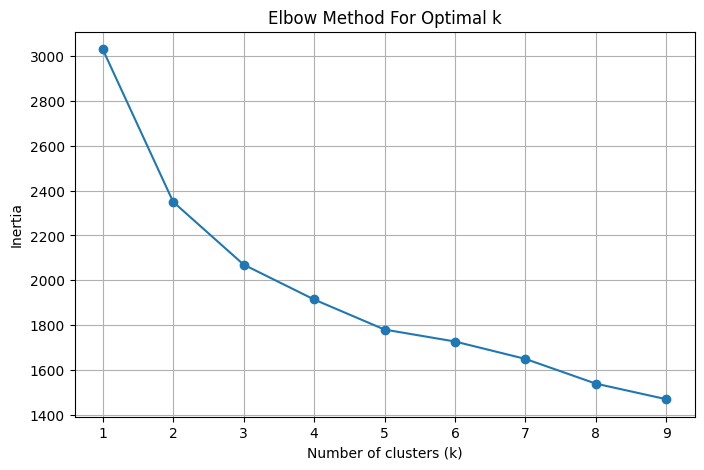

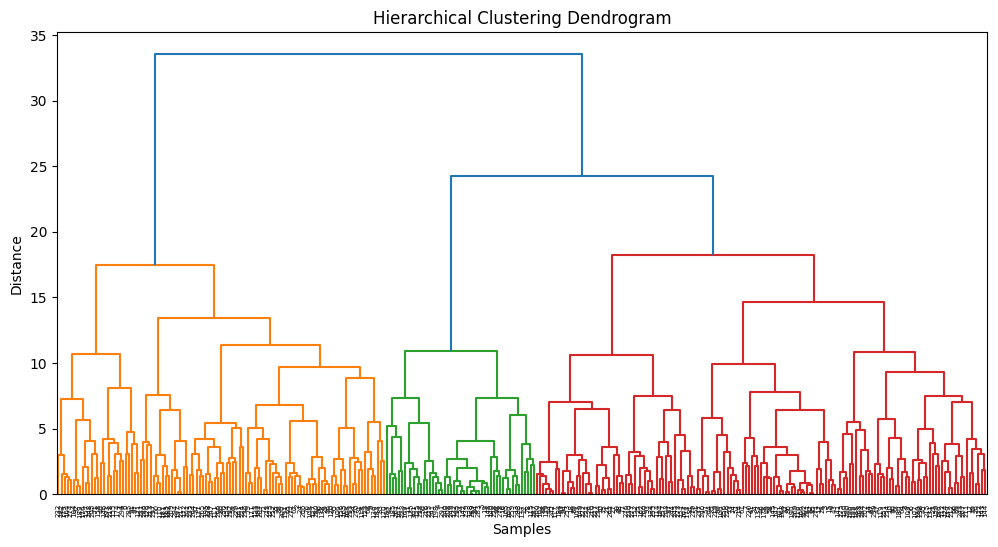

Clustering Complete.


In [6]:
# Elbow Method for K-Means
inertias = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_final)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

# Let's say optimal K is 2 (matching our binary disease labels ideally)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_final)

# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(12, 6))
dendrogram(linkage(X_final, method='ward'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

hc = AgglomerativeClustering(n_clusters=2)
hc_labels = hc.fit_predict(X_final)

print("Clustering Complete.")

## 6. Hyperparameter Tuning
- Optimize best model using GridSearchCV
- Save the final model pipeline

In [7]:
# Let's tune Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Optimized Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

# Save the best model and features
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/final_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(selected_features_rfe), '../models/selected_features.pkl')
print("Model, scaler, and features exported successfully.")

# Save Evaluation Metrics
os.makedirs('../results', exist_ok=True)
with open('../results/evaluation_metrics.txt', 'w') as f:
    f.write("Baseline Models Performance:\n")
    f.write(results_df.to_string())
    f.write("\n\nOptimized Random Forest Performance:\n")
    f.write(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}\n")
    f.write(f"Precision: {precision_score(y_test, y_pred_best):.4f}\n")
    f.write(f"Recall: {recall_score(y_test, y_pred_best):.4f}\n")
    f.write(f"F1-score: {f1_score(y_test, y_pred_best):.4f}\n")
print("Evaluation metrics saved.")

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
Optimized Accuracy: 0.9180
Model, scaler, and features exported successfully.
Evaluation metrics saved.
